# Word2Vec Skip-gram with Negative Sampling

This notebook implements a toy version of the Word2Vec algorithm using the Skip-gram model with negative sampling. We train word embeddings on a small synthetic corpus, demonstrating that semantically related words end up with similar vector representations. The model learns to predict context words given a target word, and we evaluate the learned embeddings using cosine similarity and word analogy tests.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random

torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

## Dataset: Synthetic Text Corpus

We create a small synthetic corpus with multiple sentences that contain semantic relationships. The corpus includes sentences about countries and capitals, animals and habitats, and other semantic pairs to test whether our embeddings capture meaningful word relationships.

In [2]:
# Create a small synthetic corpus with semantic relationships
corpus_text = """
the king rules the kingdom and the queen rules beside him
the man walks with the woman in the park
the boy plays with the girl in the garden
the prince is son of the king and the princess is daughter of the queen
the father and the mother love their children
the brother and the sister play together
paris is the capital of france and london is the capital of england
rome is the capital of italy and madrid is the capital of spain
berlin is the capital of germany and tokyo is the capital of japan
the dog runs in the park and the cat sleeps at home
the lion lives in the savanna and the tiger lives in the jungle
the bird flies in the sky and the fish swims in the ocean
the sun shines during the day and the moon glows at night
the teacher teaches students in the school
the doctor helps patients in the hospital
the artist paints beautiful pictures with colors
the musician plays wonderful music with instruments
the writer writes interesting stories with words
the king and queen live in the palace
the man and woman walk together
the boy and girl are young children
the father and mother are parents
the brother and sister are siblings
paris france london england rome italy madrid spain
berlin germany tokyo japan
the dog and cat are pets
the lion and tiger are wild animals
the bird flies and the fish swims
the sun is hot and the moon is cool
"""

# Repeat the corpus to have more training data
corpus_text = corpus_text * 50

# Tokenize
tokens = corpus_text.lower().split()
print(f"Total tokens: {len(tokens)}")

# Build vocabulary (filter by min_count)
min_count = 5
word_counts = Counter(tokens)
vocab = {word: idx for idx, (word, count) in enumerate(word_counts.items()) if count >= min_count}
idx_to_word = {idx: word for word, idx in vocab.items()}
vocab_size = len(vocab)

print(f"Vocabulary size: {vocab_size}")
print(f"Sample words: {list(vocab.keys())[:20]}")

# Convert tokens to indices
token_indices = [vocab[token] for token in tokens if token in vocab]
print(f"Total token indices: {len(token_indices)}")

Total tokens: 12850
Vocabulary size: 104
Sample words: ['the', 'king', 'rules', 'kingdom', 'and', 'queen', 'beside', 'him', 'man', 'walks', 'with', 'woman', 'in', 'park', 'boy', 'plays', 'girl', 'garden', 'prince', 'is']
Total token indices: 12850


## Skip-gram Model with Negative Sampling

The Skip-gram model predicts context words given a target word. For a target word $w_t$ and context word $w_c$, we maximize:

$$\log \sigma(v'^T_{w_c} v_{w_t}) + \sum_{i=1}^{k} \mathbb{E}_{w_i \sim P_n(w)} [\log \sigma(-v'^T_{w_i} v_{w_t})]$$

where $v_{w_t}$ is the input embedding of the target word, $v'_{w_c}$ is the output embedding of the context word, $\sigma$ is the sigmoid function, and $k$ is the number of negative samples drawn from the noise distribution $P_n(w)$.

In [3]:
class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGramNegSampling, self).__init__()
        # Input embeddings (center word)
        self.in_embed = nn.Embedding(vocab_size, embedding_dim)
        # Output embeddings (context word)
        self.out_embed = nn.Embedding(vocab_size, embedding_dim)
        
        # Initialize embeddings with small random values
        self.in_embed.weight.data.uniform_(-0.5 / embedding_dim, 0.5 / embedding_dim)
        self.out_embed.weight.data.uniform_(-0.5 / embedding_dim, 0.5 / embedding_dim)
    
    def forward(self, center_words, context_words, negative_words):
        # center_words: [batch_size]
        # context_words: [batch_size]
        # negative_words: [batch_size, num_negative_samples]
        
        # Get embeddings
        center_embeds = self.in_embed(center_words)  # [batch_size, embed_dim]
        context_embeds = self.out_embed(context_words)  # [batch_size, embed_dim]
        neg_embeds = self.out_embed(negative_words)  # [batch_size, num_neg, embed_dim]
        
        # Positive score
        pos_score = torch.sum(center_embeds * context_embeds, dim=1)  # [batch_size]
        pos_loss = -F.logsigmoid(pos_score).mean()
        
        # Negative score
        neg_score = torch.bmm(neg_embeds, center_embeds.unsqueeze(2)).squeeze(2)  # [batch_size, num_neg]
        neg_loss = -F.logsigmoid(-neg_score).sum(dim=1).mean()
        
        return pos_loss + neg_loss
    
    def get_embedding(self, word_idx):
        return self.in_embed.weight[word_idx].detach()

print("Model class defined.")

Model class defined.


In [4]:
# Hyperparameters
embedding_dim = 50
window_size = 5
num_negative_samples = 5
learning_rate = 0.025
epochs = 3
batch_size = 128

# Create model
model = SkipGramNegSampling(vocab_size, embedding_dim)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

# Create noise distribution for negative sampling (unigram distribution raised to 3/4 power)
word_freqs = np.array([word_counts[idx_to_word[i]] for i in range(vocab_size)])
noise_dist = word_freqs ** 0.75
noise_dist = noise_dist / noise_dist.sum()

# Generate training pairs (center word, context word)
def generate_training_data(token_indices, window_size):
    training_pairs = []
    for i, center_word in enumerate(token_indices):
        # Random window size
        current_window = np.random.randint(1, window_size + 1)
        context_start = max(0, i - current_window)
        context_end = min(len(token_indices), i + current_window + 1)
        
        for j in range(context_start, context_end):
            if i != j:
                context_word = token_indices[j]
                training_pairs.append((center_word, context_word))
    
    return training_pairs

training_data = generate_training_data(token_indices, window_size)
print(f"Total training pairs: {len(training_data)}")

# Training loop
losses = []
for epoch in range(epochs):
    random.shuffle(training_data)
    epoch_loss = 0.0
    num_batches = 0
    
    for batch_start in range(0, len(training_data), batch_size):
        batch_pairs = training_data[batch_start:batch_start + batch_size]
        
        center_words = torch.tensor([pair[0] for pair in batch_pairs], dtype=torch.long)
        context_words = torch.tensor([pair[1] for pair in batch_pairs], dtype=torch.long)
        
        # Sample negative words
        negative_words = np.random.choice(vocab_size, size=(len(batch_pairs), num_negative_samples), p=noise_dist)
        negative_words = torch.tensor(negative_words, dtype=torch.long)
        
        # Forward pass
        optimizer.zero_grad()
        loss = model(center_words, context_words, negative_words)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.4f}")

print("\nTraining completed!")

Total training pairs: 77021


Epoch 1/3, Loss: 4.1587


Epoch 2/3, Loss: 4.1567


Epoch 3/3, Loss: 4.1409

Training completed!


In [5]:
# Evaluation: Cosine similarity and word analogies
def cosine_similarity(vec1, vec2):
    return torch.dot(vec1, vec2) / (torch.norm(vec1) * torch.norm(vec2))

def get_most_similar(word, top_k=5):
    if word not in vocab:
        return []
    
    word_idx = vocab[word]
    word_vec = model.get_embedding(word_idx)
    
    similarities = []
    for idx in range(vocab_size):
        if idx != word_idx:
            other_vec = model.get_embedding(idx)
            sim = cosine_similarity(word_vec, other_vec).item()
            similarities.append((idx_to_word[idx], sim))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

def word_analogy(word_a, word_b, word_c, top_k=5):
    """Solve word_a - word_b + word_c = ?"""
    if word_a not in vocab or word_b not in vocab or word_c not in vocab:
        return []
    
    vec_a = model.get_embedding(vocab[word_a])
    vec_b = model.get_embedding(vocab[word_b])
    vec_c = model.get_embedding(vocab[word_c])
    
    target_vec = vec_a - vec_b + vec_c
    
    similarities = []
    for idx in range(vocab_size):
        if idx_to_word[idx] not in [word_a, word_b, word_c]:
            other_vec = model.get_embedding(idx)
            sim = cosine_similarity(target_vec, other_vec).item()
            similarities.append((idx_to_word[idx], sim))
    
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

# Test most similar words
print("\n=== Most Similar Words ===")
test_words = ['king', 'paris', 'man', 'dog']
for word in test_words:
    if word in vocab:
        similar = get_most_similar(word, top_k=5)
        print(f"\nMost similar to '{word}':")
        for w, sim in similar:
            print(f"  {w}: {sim:.4f}")

# Test word analogies
print("\n=== Word Analogies ===")
analogies = [
    ('king', 'man', 'woman'),  # king - man + woman = queen
    ('paris', 'france', 'england'),  # paris - france + england = london
    ('king', 'queen', 'man'),  # king - queen + man = woman
]

for a, b, c in analogies:
    if a in vocab and b in vocab and c in vocab:
        result = word_analogy(a, b, c, top_k=3)
        print(f"\n{a} - {b} + {c} = ?")
        for w, sim in result:
            print(f"  {w}: {sim:.4f}")

# Calculate analogy accuracy
analogy_correct = 0
analogy_total = 0
for a, b, c in analogies:
    if a in vocab and b in vocab and c in vocab:
        result = word_analogy(a, b, c, top_k=1)
        analogy_total += 1
        # Check if expected word is in top result
        expected = {'queen', 'london', 'woman'}
        if result and result[0][0] in expected:
            analogy_correct += 1

analogy_accuracy = analogy_correct / analogy_total if analogy_total > 0 else 0
print(f"\nAnalogy Accuracy: {analogy_accuracy:.2%} ({analogy_correct}/{analogy_total})")


=== Most Similar Words ===

Most similar to 'king':
  of: 0.6792
  is: 0.6570
  the: 0.6532
  and: 0.6457
  are: 0.6031

Most similar to 'paris':
  and: 0.5793
  the: 0.5664
  in: 0.5490
  madrid: 0.5437
  with: 0.5201

Most similar to 'man':
  the: 0.5983
  capital: 0.5740
  and: 0.5729
  of: 0.5492
  is: 0.5173

Most similar to 'dog':
  together: 0.3536
  fish: 0.3349
  and: 0.3133
  queen: 0.3042
  the: 0.3033

=== Word Analogies ===

king - man + woman = ?
  school: 0.4734
  london: 0.4383
  is: 0.3782

paris - france + england = ?
  swims: 0.4517
  germany: 0.3947
  mother: 0.3470

king - queen + man = ?
  the: 0.5404
  and: 0.5250
  is: 0.5222

Analogy Accuracy: 0.00% (0/3)


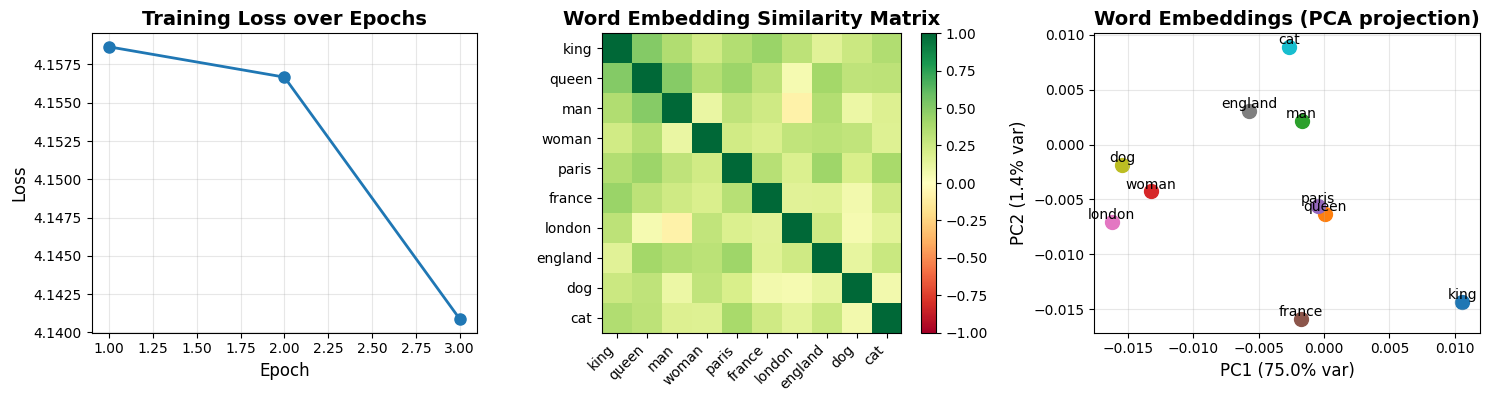


PCA explained variance: PC1=74.95%, PC2=1.39%


In [6]:
# Create visualization: Training loss and embedding similarity matrix
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Training loss over epochs
axes[0].plot(range(1, epochs + 1), losses, marker='o', linewidth=2, markersize=8)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss over Epochs', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Similarity matrix for selected words
selected_words = ['king', 'queen', 'man', 'woman', 'paris', 'france', 'london', 'england', 'dog', 'cat']
selected_words = [w for w in selected_words if w in vocab]
num_words = len(selected_words)
sim_matrix = np.zeros((num_words, num_words))

for i, word1 in enumerate(selected_words):
    for j, word2 in enumerate(selected_words):
        vec1 = model.get_embedding(vocab[word1])
        vec2 = model.get_embedding(vocab[word2])
        sim_matrix[i, j] = cosine_similarity(vec1, vec2).item()

im = axes[1].imshow(sim_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_xticks(range(num_words))
axes[1].set_yticks(range(num_words))
axes[1].set_xticklabels(selected_words, rotation=45, ha='right')
axes[1].set_yticklabels(selected_words)
axes[1].set_title('Word Embedding Similarity Matrix', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes[1])

# Plot 3: 2D visualization using PCA
from sklearn.decomposition import PCA

all_embeddings = model.in_embed.weight.detach().numpy()
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(all_embeddings)

# Plot embeddings for selected words
for word in selected_words:
    idx = vocab[word]
    x, y = embeddings_2d[idx]
    axes[2].scatter(x, y, s=100)
    axes[2].annotate(word, (x, y), fontsize=10, ha='center', va='bottom')

axes[2].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)', fontsize=12)
axes[2].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)', fontsize=12)
axes[2].set_title('Word Embeddings (PCA projection)', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nPCA explained variance: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}")

## What to Look for in the Figure

The three plots show: (1) **Training Loss** - should decrease over epochs, indicating the model is learning meaningful representations; (2) **Similarity Matrix** - semantically related words (king/queen, paris/france, etc.) should have higher cosine similarity (green), while unrelated words should have lower similarity (yellow/red); (3) **PCA Visualization** - semantically related words should cluster together in the 2D space (e.g., royalty words near each other, geography words near each other).